# Face Recognition -  Using Deep Face

In [ ]:
# !mkdir -p project
# !mkdir -p project/known_faces/


In [ ]:
# !tree -r project/

project/
├── mohanlal_test_1.jpeg
└── known_faces
    ├── mohanlal_1.jpg
    └── mammootty_1.jpg

1 directory, 3 files


In [ ]:
# pip install deepface

In [ ]:
# !ls face_recog*.ipynb

In [ ]:
import os
os.getcwd()


'/content'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !apt install tree
!tree /content/drive/MyDrive/face_recognition

/content/drive/MyDrive/face_recognition
├── face_recognition_deepface.ipynb
└── project
    ├── known_faces
    │   ├── mammootty_1.jpg
    │   └── mohanlal_1.jpg
    └── mohanlal_test_1.jpeg

2 directories, 4 files


In [ ]:
import numpy
print(numpy.__version__)


2.0.2


In [ ]:
%%time

from deepface import DeepFace
import os

known_faces_path = "/content/drive/MyDrive/face_recognition/project/known_faces"

known_embeddings = []

for file in os.listdir(known_faces_path):
    identity = file.split(".")[0]
    path = os.path.join(known_faces_path, file)

    embedding = DeepFace.represent(img_path=path, model_name="Facenet")[0]["embedding"]
    known_embeddings.append((identity, embedding))


25-07-01 10:57:48 - facenet_weights.h5 will be downloaded...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet_weights.h5
To: /root/.deepface/weights/facenet_weights.h5
100%|██████████| 92.2M/92.2M [00:00<00:00, 130MB/s]


CPU times: user 8.67 s, sys: 856 ms, total: 9.52 s
Wall time: 10.5 s


In [ ]:
from deepface import DeepFace
import os
import pickle

# 🔹 Check if cache file exists
cache_file = "/content/drive/MyDrive/face_recognition/known_embeddings.pkl"

# 🔹 If cache file does not exist, compute and save
if not os.path.exists(cache_file):
    known_embeddings = []

    for file in os.listdir(known_faces_path):
        identity = file.split(".")[0]
        path = os.path.join(known_faces_path, file)

        embedding = DeepFace.represent(img_path=path, model_name="Facenet")[0]["embedding"]
        known_embeddings.append((identity, embedding))

    # 🔹 Save to pickle
    with open(cache_file, "wb") as f:
        pickle.dump(known_embeddings, f)

    print("✅ Embeddings saved to cache!")
else:
    print("✅ Cache file already exists. You can load it.")


# import pickle

# with open("known_embeddings.pkl", "rb") as f:
#     known_embeddings = pickle.load(f)

# print("✅ Embeddings loaded from cache!")


✅ Embeddings saved to cache!


In [ ]:
%%time

from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

test_img = "/content/drive/MyDrive/face_recognition/project/mohanlal_test_1.jpeg"
test_embedding = DeepFace.represent(img_path=test_img, model_name="Facenet")[0]["embedding"]

# Save test embedding to .pkl
with open("/content/drive/MyDrive/face_recognition/test_embedding.pkl", "wb") as f:
    pickle.dump(test_embedding, f)

print("✅ Test embedding saved to test_embedding.pkl")


# Compare with known faces
threshold = 0.5
match = "Unknown"

for name, emb in known_embeddings:
    sim = cosine_similarity([test_embedding], [emb])[0][0]
    if sim > threshold:
        match = name
        break

print(f"✅ Recognized: {match}")



✅ Test embedding saved to test_embedding.pkl
✅ Recognized: mohanlal_1
CPU times: user 473 ms, sys: 18.5 ms, total: 492 ms
Wall time: 401 ms


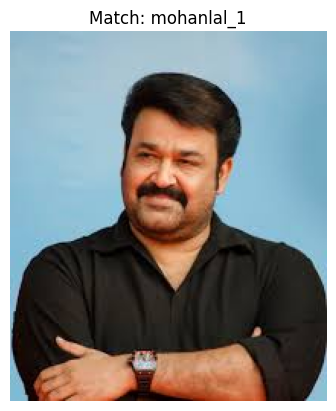

In [ ]:

import cv2
from matplotlib import pyplot as plt

img = cv2.imread(test_img)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title(f"Match: {match}")
plt.axis("off")
plt.show()